In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# DATASET

In [2]:
nps_dataset = pd.read_csv('datasetNPS/PENTION_EI_Complete.csv', sep=',', header=0)

print(f'The dataset has {nps_dataset.shape[0]} instances and {nps_dataset.shape[1]} features.')
nps_dataset.head()

The dataset has 2600 instances and 602 features.


,Name,1,2,3,4,5,6,7,8,9,...,592,593,594,595,596,597,598,599,600,label
0,(Iso)butyryl-F-fentanyl N-benzyl analogue,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,"1-(1,3-Diphenylpropan-2-yl)pyrrolidine",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,1-(1-Phenylcyclohexyl)azepane,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,1-(1-Phenylcyclohexyl)azetidine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,"1-(2,3,4-Trimethoxybenzyl)piperazine",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [3]:
nps_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Columns: 602 entries, Name to label
dtypes: float64(600), int64(1), object(1)
memory usage: 11.9+ MB


In [4]:
nps_dataset.describe()

,1,2,3,4,5,6,7,8,9,10,...,592,593,594,595,596,597,598,599,600,label
count,2600.0,2600.0,2600.0,2600.0,2600.0,2600.0,2600.0,2600.0,2600.0,2600.0,...,2600.000000,2600.000000,2600.0,2600.000000,2600.000000,2600.0,2600.0,2600.000000,2600.0,2600.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000008,0.000004,0.0,0.000004,0.000008,0.0,0.0,0.000392,0.0,2.920769
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000277,0.000196,0.0,0.000196,0.000277,0.0,0.0,0.019613,0.0,2.303591
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,1.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,2.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,5.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.010000,0.010000,0.0,0.010000,0.010000,0.0,0.0,1.000000,0.0,6.000000


In [5]:
print(nps_dataset.isnull().sum(axis=1))

0       0
1       0
2       0
3       0
4       0
       ..
2595    0
2596    0
2597    0
2598    0
2599    0
Length: 2600, dtype: int64


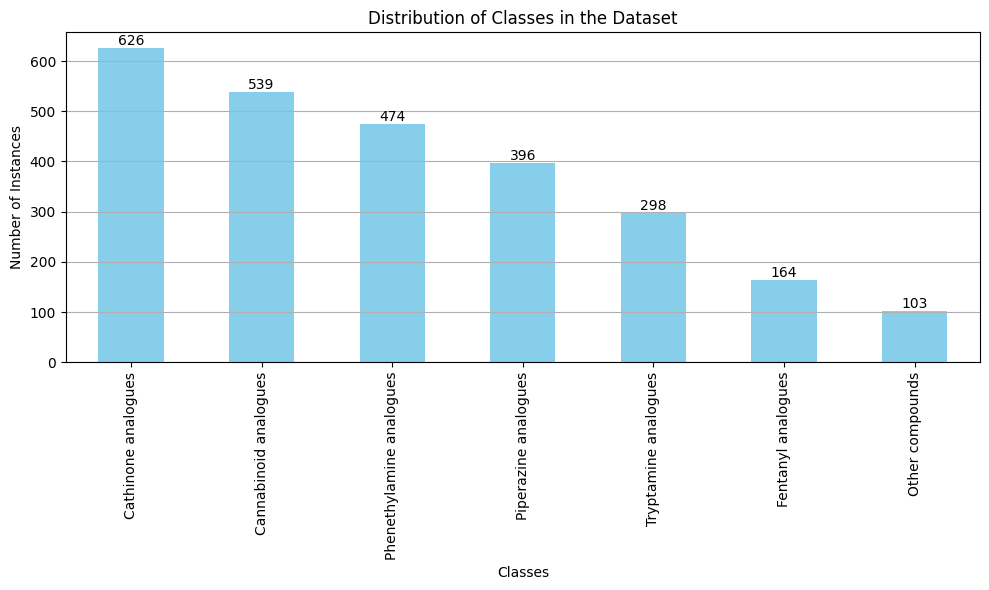

In [6]:
classes = ['Cathinone analogues', 'Cannabinoid analogues',
           'Phenethylamine analogues', 'Piperazine analogues',
           'Tryptamine analogues', 'Fentanyl analogues', 'Other compounds']

distributions = nps_dataset['label'].value_counts()

legends = {
  0: 'Cathinone analogues',
  1: 'Cannabinoid analogues',
  2: 'Phenethylamine analogues',
  3: 'Piperazine analogues',
  4: 'Tryptamine analogues',
  5: 'Fentanyl analogues',
  6: 'Other compounds'
}

plt.figure(figsize=(10, 6))
ax = distributions.plot(kind='bar', color='skyblue')
plt.title('Distribution of Classes in the Dataset')
plt.xlabel('Classes')
plt.ylabel('Number of Instances')
plt.xticks(ticks=range(len(classes)), labels=[legends[i] for i in range(len(classes))], rotation=90)
plt.grid(axis='y')
plt.tight_layout()

for p in ax.patches:
  ax.annotate(str(int(p.get_height())), 
        (p.get_x() + p.get_width() / 2, p.get_height()), 
        ha='center', va='bottom', fontsize=10)

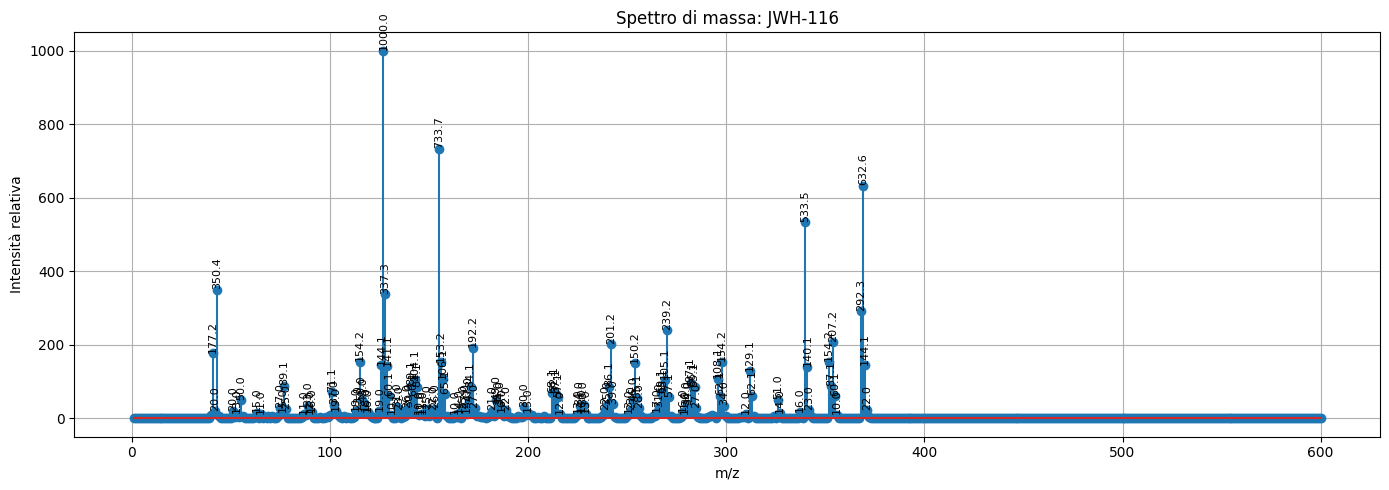

In [7]:
# Nello spettrometro di massa, il segnale sotto m/z 40 è spesso rumore o non rilevante per droghe sintetiche o 
# sostanze organiche complesse. 
#nps_dataset = nps_dataset.drop(columns=nps_dataset.columns[1:41])
#print(f'The dataset has {nps_dataset.shape[0]} instances and {nps_dataset.shape[1]} features after removing noise columns.')

# === spettro di massa ===
nome = "JWH-116"
riga = nps_dataset[nps_dataset.iloc[:, 0] == nome].iloc[0]

spettro = riga[1:-1].astype(float).values 
mz = list(range(1, 601))

# Plot con etichette
plt.figure(figsize=(14, 5))
(markerline, stemlines, baseline) = plt.stem(mz, spettro)
plt.xlabel("m/z")
plt.ylabel("Intensità relativa")
plt.title(f"Spettro di massa: {nome}")
plt.grid(True)

soglia = 10.0
for mzi, intensita in zip(mz, spettro):
    if intensita > soglia:
        plt.text(mzi, intensita + 1, f"{intensita:.1f}", ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# DATA AUGMENTATION

To increase the robustness of the training and compensate
for the limited number of data points, data augmentation was
applied. The abundance values were increased by random
value in the range 0.01 to 9.99%. Such an augmentation
changes the absolute values of m/z intensities without changing
their proportion, i.e. the pattern. This augmentation step was
repeated to obtain four additional data points for each segment

In [8]:
def augment_spectrum(spettro, moltiplicatore=10, percentuale_variabile=0.1):
    augmented = []

    for _ in range(moltiplicatore):
        # Applica variazione casuale ±10%
        variazione = 1 + np.random.uniform(-percentuale_variabile, percentuale_variabile, size=len(spettro))
        spettro_variato = spettro * variazione

        # Rinormalizza: picco massimo = 100
        spettro_normalizzato = spettro_variato / spettro_variato.max() * 100
        augmented.append(spettro_normalizzato)

    return augmented

righe_augmented = []

print(nps_dataset.shape)
print(nps_dataset[1:-1].shape)


for idx, row in nps_dataset.iterrows():
    nome = row["Name"]
    categoria = row["label"]
    spettro = row[1:-1].astype(float).values  # valori m/z 

    # Genera 10 spettrogrammi aumentati
    augmented = augment_spectrum(spettro, moltiplicatore=10)

    for spettro_aug in augmented:
        nuova_riga = [nome] + list(spettro_aug) + [categoria]
        righe_augmented.append(nuova_riga)

colonne = ["Name"] + list(range(1, 601)) + ["label"]
df_augmented = pd.DataFrame(righe_augmented, columns=colonne)
print(f'The augmented dataset has {df_augmented.shape[0]} instances and {df_augmented.shape[1]} features.')
df_augmented


(2600, 602)
(2598, 602)
The augmented dataset has 26000 instances and 602 features.


,Name,1,2,3,4,5,6,7,8,9,...,592,593,594,595,596,597,598,599,600,label
0,(Iso)butyryl-F-fentanyl N-benzyl analogue,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,(Iso)butyryl-F-fentanyl N-benzyl analogue,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,(Iso)butyryl-F-fentanyl N-benzyl analogue,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
3,(Iso)butyryl-F-fentanyl N-benzyl analogue,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
4,(Iso)butyryl-F-fentanyl N-benzyl analogue,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25995,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
25996,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
25997,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
25998,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6


# FEATURE ENGINEERING

Base Peak Mass: Mass-to-charge ratio (m/z) of the peak with the greatest intensity (i.e., “base peak”) 

Base Peak Mass Proximity: m/z difference between base peak and the peak with the nearest m/z value 

Maximum Mass: m/z of the peak with the greatest mass 

Maximum Mass Proximity: m/z difference between maximum-mass peak and the peak with the nearest m/z value 

Number of Peaks: Total number of reported peaks in the spectrum 

Intensity Mean: Mean of all peaks’ intensity values 

Intensity Standard Deviation Standard: deviation of all peaks’ intensity values 

Intensity Density: Maximum intensity divided by number of peaks 
Mass Mean: Mean of all peaks’ m/z 
Mass Standard Deviation: Standard deviation of all peaks’ m/z Mass Density; Maximum mass divided by number of peaks 
Most Frequent Pair Peakwise Mass Difference (PPMD): Most frequent m/z difference among all pairs of peaks 

Mean PPMD: Mean of m/z differences among all pairs of peaks 

In [9]:
import numpy as np

mz_range = np.arange(1, 601)
spectra = nps_dataset[mz_range.astype(str)].values

def compute_features(spectrum):
    peaks = [(mz, intensity) for mz, intensity in zip(mz_range, spectrum) if intensity > 0]
    if not peaks:
        return [np.nan] * 13

    mz_values, intensities = zip(*peaks)
    mz_values = np.array(mz_values)
    intensities = np.array(intensities)

    # Base Peak Mass
    base_peak_idx = np.argmax(intensities)
    base_peak_mass = mz_values[base_peak_idx] 
    
    # Base Peak Proximity
    if len(mz_values) > 1:
        mz_diff_base = np.abs(mz_values - base_peak_mass)
        base_prox = np.partition(mz_diff_base[mz_diff_base != 0], 0)[0]
    else:
        base_prox = 0.0

    # Maximum Mass
    max_mass = np.max(mz_values)

    # Maximum Mass Proximity
    if len(mz_values) > 1:
        mz_diff_max = np.abs(mz_values - max_mass)
        max_prox = np.partition(mz_diff_max[mz_diff_max != 0], 0)[0]
    else:
        max_prox = 0.0

    # Number of Peaks
    num_peaks = len(peaks)

    # Intensity stats
    intensity_mean = np.mean(intensities)
    intensity_std = np.std(intensities)
    intensity_density = np.max(intensities) / num_peaks

    # Mass stats
    mass_mean = np.mean(mz_values)
    mass_std = np.std(mz_values)
    mass_density = max_mass / num_peaks

    # Pairwise Peak Mass Differences
    diffs = np.abs(np.subtract.outer(mz_values, mz_values))
    diffs = diffs[np.triu_indices(len(diffs), k=1)]
    diff_counts = np.bincount(np.round(diffs).astype(int))
    ppmd = np.argmax(diff_counts)
    mean_ppmd = np.mean(diffs)

    return [
        base_peak_mass, base_prox, max_mass, max_prox,
        num_peaks, intensity_mean, intensity_std, intensity_density,
        mass_mean, mass_std, mass_density, ppmd, mean_ppmd
    ]

features = np.array([compute_features(spectrum) for spectrum in spectra])

feature_columns = [
    "BasePeakMass", "BasePeakMassProximity", "MaxMass", "MaxMassProximity",
    "NumPeaks", "IntensityMean", "IntensityStd", "IntensityDensity",
    "MassMean", "MassStd", "MassDensity", "PPMD", "MeanPPMD"
]

features_df = pd.DataFrame(features, columns=feature_columns)
full_df = pd.concat([nps_dataset[["Name", "label"]], features_df], axis=1)
full_df.head()


,Name,label,BasePeakMass,BasePeakMassProximity,MaxMass,MaxMassProximity,NumPeaks,IntensityMean,IntensityStd,IntensityDensity,MassMean,MassStd,MassDensity,PPMD,MeanPPMD
0,(Iso)butyryl-F-fentanyl N-benzyl analogue,5,245.0,1.0,352.0,55.0,122.0,41.607295,113.080752,8.196721,122.754098,57.868890,2.885246,1.0,64.123019
1,"1-(1,3-Diphenylpropan-2-yl)pyrrolidine",3,174.0,1.0,264.0,1.0,83.0,28.967470,114.396718,12.048193,117.566265,52.144422,3.180723,1.0,58.902145
2,1-(1-Phenylcyclohexyl)azepane,2,214.0,1.0,259.0,1.0,128.0,43.277969,108.422544,7.812500,129.617188,55.771594,2.023438,14.0,63.985359
3,1-(1-Phenylcyclohexyl)azetidine,2,98.0,1.0,217.0,1.0,135.0,67.734815,127.593874,7.407407,115.703704,46.709357,1.607407,1.0,53.855832
4,"1-(2,3,4-Trimethoxybenzyl)piperazine",3,181.0,1.0,267.0,1.0,113.0,40.952743,106.344352,8.849558,137.592920,59.738018,2.362832,1.0,68.825853


# ANALISI ESPLORATIVA

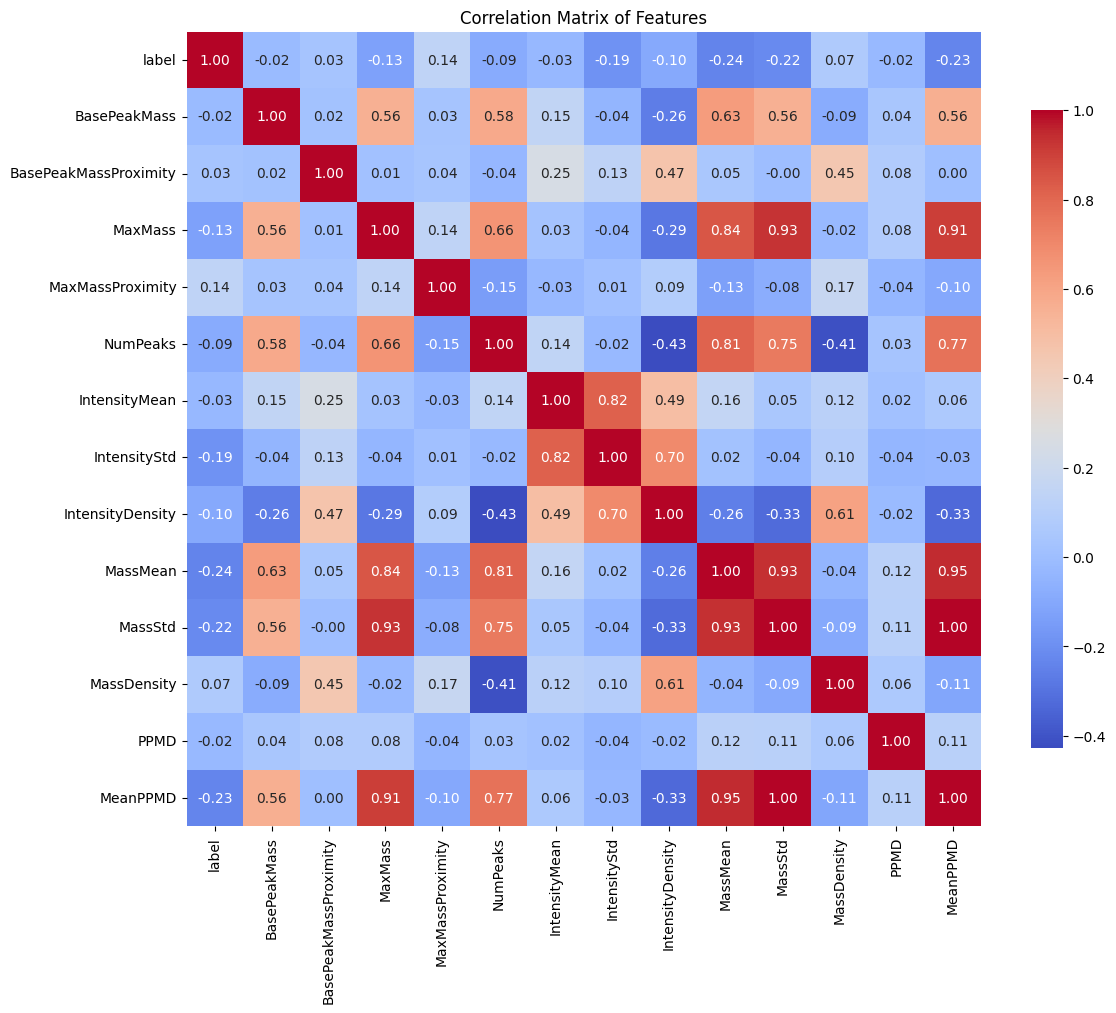

In [10]:
import seaborn as sns
full_df.drop(columns=['Name'], inplace=True)
plt.figure(figsize=(12, 10))
sns.heatmap(full_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = full_df.drop(columns=['label'])
y = full_df['label']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns)

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.80
to_drop = set()

for col in upper.columns:
    correlated_features = upper.index[upper[col] > threshold].tolist()
    for corr_feat in correlated_features:
        if importances[col] < importances[corr_feat]:
            to_drop.add(col)
        else:
            to_drop.add(corr_feat)

print(f"Variabili rimosse tenendo conto di importanza e correlazione (> {threshold}):", to_drop)

full_df= full_df.drop(columns=list(to_drop))

feature_columns= full_df.drop(columns=['label']).columns.tolist()
full_df.head()

Variabili rimosse tenendo conto di importanza e correlazione (> 0.8): {'IntensityStd', 'MassStd', 'MeanPPMD', 'MaxMass', 'NumPeaks'}


,label,BasePeakMass,BasePeakMassProximity,MaxMassProximity,IntensityMean,IntensityDensity,MassMean,MassDensity,PPMD
0,5,245.0,1.0,55.0,41.607295,8.196721,122.754098,2.885246,1.0
1,3,174.0,1.0,1.0,28.967470,12.048193,117.566265,3.180723,1.0
2,2,214.0,1.0,1.0,43.277969,7.812500,129.617188,2.023438,14.0
3,2,98.0,1.0,1.0,67.734815,7.407407,115.703704,1.607407,1.0
4,3,181.0,1.0,1.0,40.952743,8.849558,137.592920,2.362832,1.0


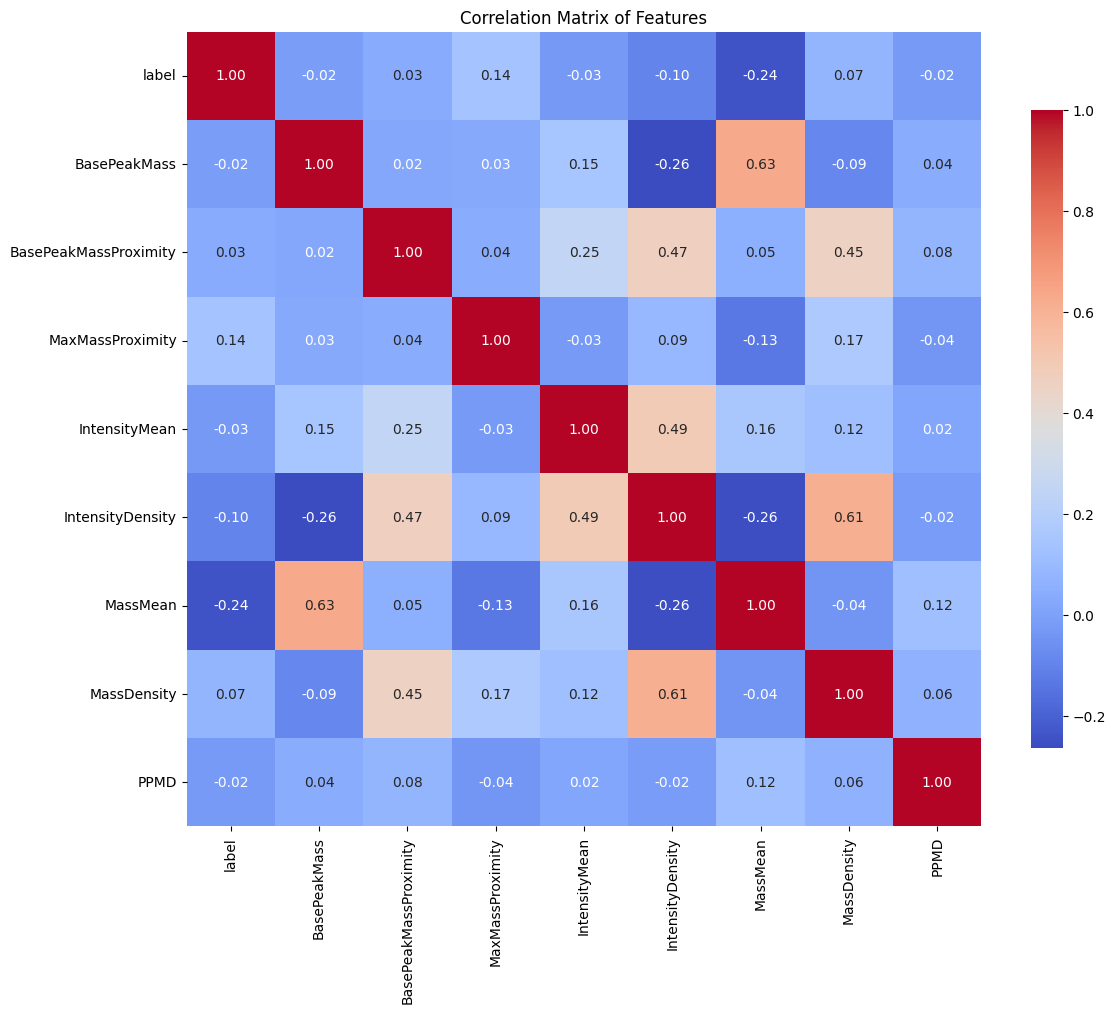

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(full_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()


Si preservano le feature più rilevanti per il modello evitando di rimuovere variabili a caso che possono essere importanti

# MODELLING


In [13]:
import pandas as pd
import numpy as np
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Caricamento e preparazione dei dati 
df = full_df.copy()  

Y = df['label']
X = df.drop(['label'], axis=1)

X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f'The training set has {x_train.shape[0]} instances and {x_train.shape[1]} features.')
print(f'The test set has {x_test.shape[0]} instances and {x_test.shape[1]} features.')

# Oversampling
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

print(pd.Series(y_train).value_counts())


(2600, 8) (2600,)
The training set has 2080 instances and 8 features.
The test set has 520 instances and 8 features.
4    501
0    501
1    501
2    501
6    501
5    501
3    501
Name: count, dtype: int64


=== Classification Report ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.83      0.89      0.86       125
   Cannabinoid analogues       0.66      0.68      0.67        59
Phenethylamine analogues       0.69      0.68      0.69        79
    Piperazine analogues       0.42      0.48      0.44        21
    Tryptamine analogues       0.61      0.58      0.59        33
      Fentanyl analogues       0.83      0.87      0.85       108
         Other compounds       0.75      0.62      0.68        95

                accuracy                           0.74       520
               macro avg       0.68      0.68      0.68       520
            weighted avg       0.74      0.74      0.74       520


=== Confusion Matrix ===


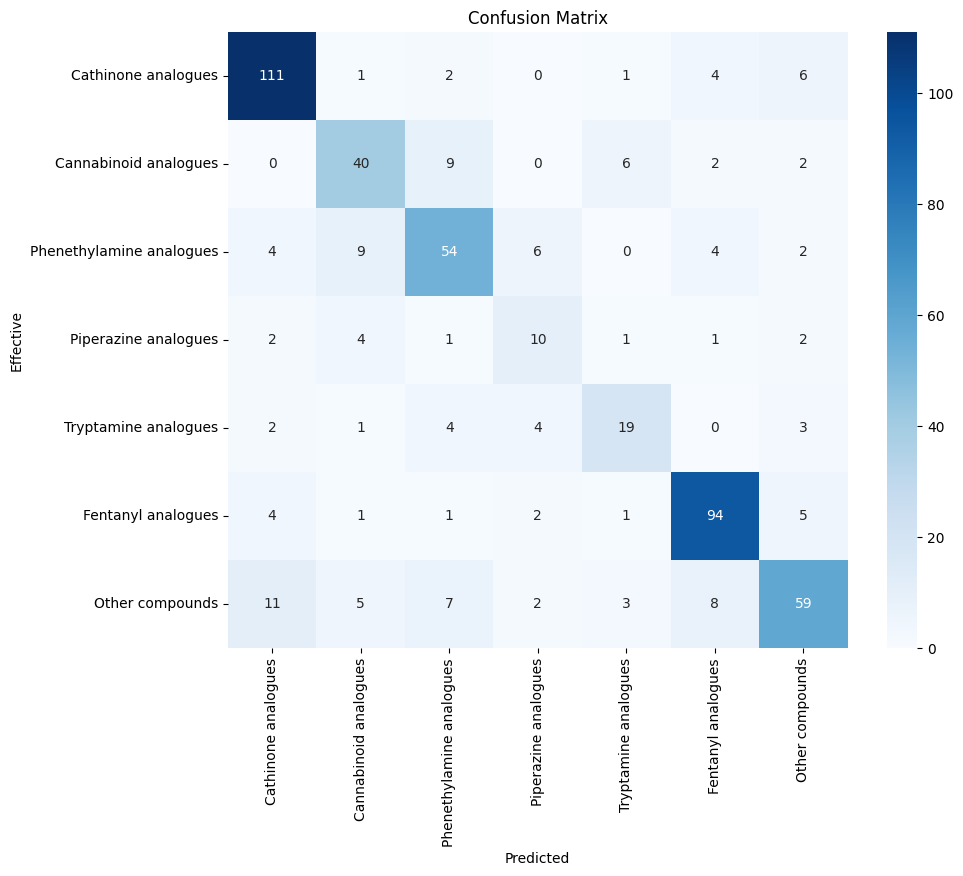


Cross-validation accuracy (4-fold): 0.81 ± 0.04


In [14]:
import seaborn as sns

# Classificatore Balanced Random Forest 
clf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)

# Valutazione
y_pred = clf.predict(x_test)
print("=== Classification Report ===")
class_labels = [legends[i] for i in clf.classes_]
print(classification_report(y_test, y_pred, target_names=class_labels))
print("\n=== Confusion Matrix ===")
confusion_matrix_result = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()    

# Cross-validation 
scores = cross_val_score(clf, x_train, y_train, cv=4)
print(f"\nCross-validation accuracy (4-fold): {scores.mean():.2f} ± {scores.std():.2f}")

In [15]:
import joblib

In [16]:
joblib.dump(clf, 'model/balanced_random_forest_brf.pkl')

['model/balanced_random_forest_brf.pkl']

C:\Users\marco\AppData\Local\Temp\ipykernel_29808\2159856053.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


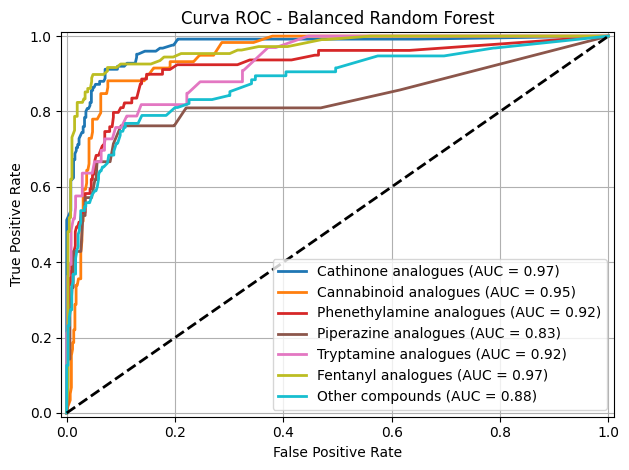

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(x_test)

# Curva ROC (multi-classe One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.


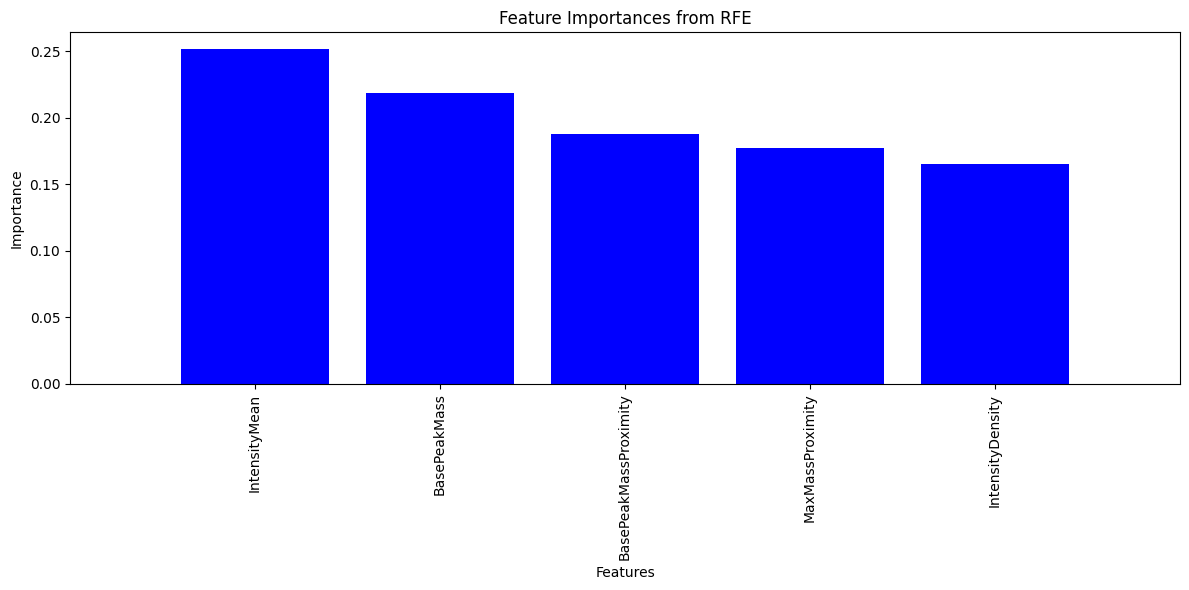

In [18]:
#feature importance
from sklearn.feature_selection import RFE
rfe_base_clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rfe = RFE(rfe_base_clf, n_features_to_select=5, verbose=1)
clf_rfe.fit(x_train, y_train)

importances = clf_rfe.estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot delle feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importances from RFE")
plt.bar(range(len(importances)), importances[indices], color='b', align='center')
plt.xticks(range(len(importances)), [feature_columns[i] for i in indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Feature selezionate: ['BasePeakMass' 'IntensityMean' 'IntensityDensity' 'MassMean'
 'MassDensity']
=== Classification Report after RFE ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.83      0.82      0.83       125
   Cannabinoid analogues       0.65      0.68      0.66        59
Phenethylamine analogues       0.70      0.71      0.70        79
    Piperazine analogues       0.42      0.52      0.47        21
    Tryptamine analogues       0.55      0.52      0.53        33
      Fentanyl analogues       0.82      0.87      0.84       108
         Other compounds       0.73      0.63      0.68        95

                accuracy                           0.73       520
               macro avg       0.67      0.68      0.67       520
            weighted avg       0.73      0.73      0.73       520



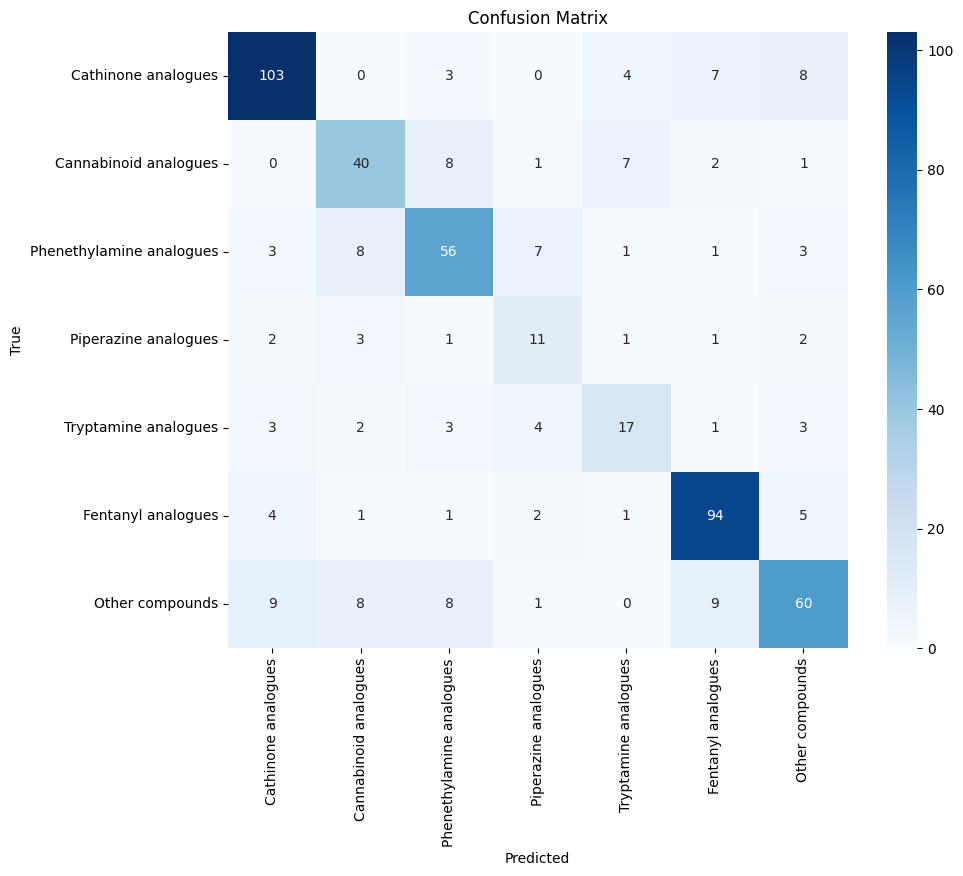


Cross-validation accuracy (4-fold) after RFE: 0.80 ± 0.02


In [19]:
# Selezione boolean array delle feature scelte da RFE
selected_indices = clf_rfe.support_

selected_features = np.array(feature_columns)[selected_indices]
print("Feature selezionate:", selected_features)

if isinstance(x_train, pd.DataFrame):
    X_train_selected = x_train.loc[:, selected_features].values
    X_test_selected = x_test.loc[:, selected_features].values
else:
    X_train_selected = x_train[:, selected_indices]
    X_test_selected = x_test[:, selected_indices]

bdt_clf_rfe = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
bdt_clf_rfe.fit(X_train_selected, y_train)

y_pred_rfe = bdt_clf_rfe.predict(X_test_selected)

print("=== Classification Report after RFE ===")
print(classification_report(y_test, y_pred_rfe, target_names=class_labels))

confusion_matrix_result = confusion_matrix(y_test, y_pred_rfe)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
plt.show()

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
scores = cross_val_score(bdt_clf_rfe, X_train_selected, y_train, cv=cv)

print(f"\nCross-validation accuracy (4-fold) after RFE: {scores.mean():.2f} ± {scores.std():.2f}")


In [20]:
joblib.dump(bdt_clf_rfe, 'model/balanced_random_forest_rfe.pkl')

['model/balanced_random_forest_rfe.pkl']

C:\Users\marco\AppData\Local\Temp\ipykernel_29808\2899310292.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


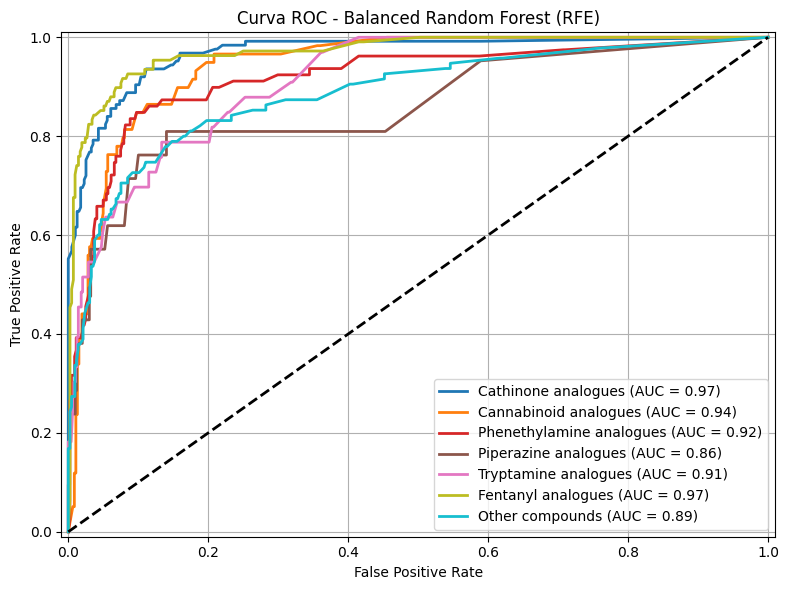

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score_rfe = bdt_clf_rfe.predict_proba(X_test_selected)

# Calcola fpr, tpr, auc per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_rfe[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest (RFE)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Best parameters found:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20, 'criterion': 'entropy'}
Best cross-validation score:  0.7944111776447106

=== Classification Report (Best Model) ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.79      0.89      0.83       125
   Cannabinoid analogues       0.64      0.64      0.64        59
Phenethylamine analogues       0.66      0.67      0.67        79
    Piperazine analogues       0.42      0.52      0.47        21
    Tryptamine analogues       0.61      0.58      0.59        33
      Fentanyl analogues       0.82      0.84      0.83       108
         Other compounds       0.76      0.58      0.66        95

                accuracy                           0.73       520
               macro avg       0.67      0.67      0.67       520
            weighted avg       0.73      0.73      0.72       520


=== Confusion Matrix (Best Model) ===


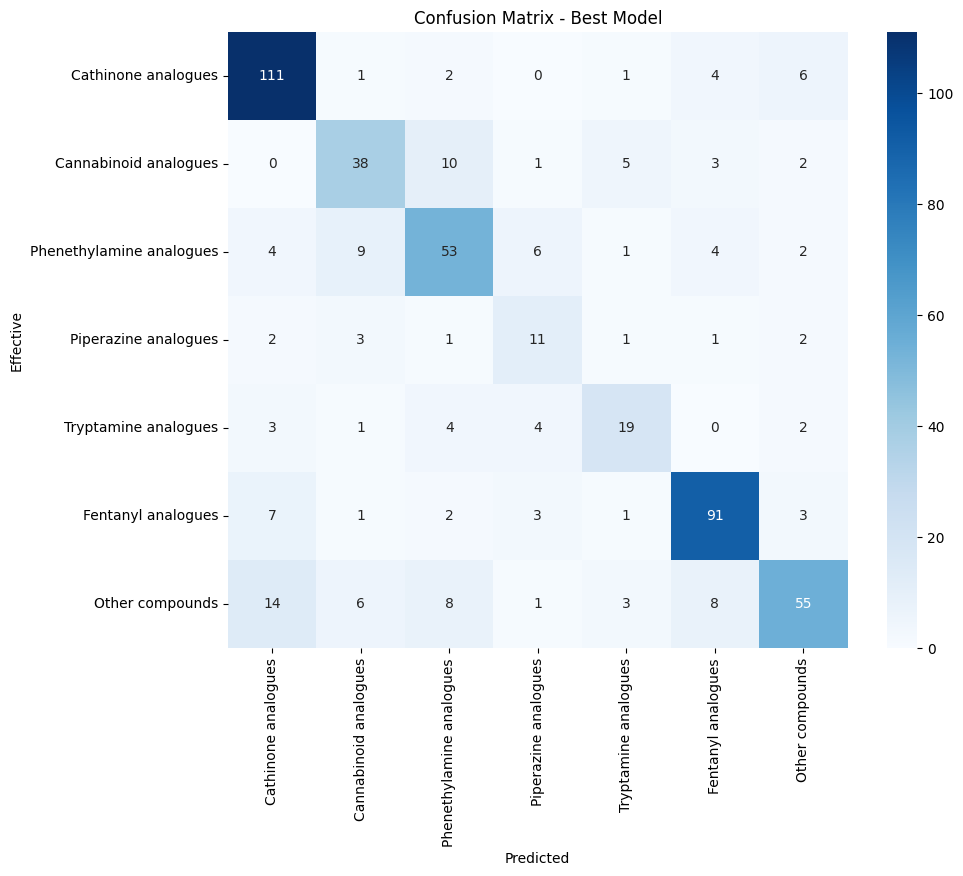


=== Cross-validation score (Best Model) ===
Cross-validation accuracy (4-fold): 0.59 ± 0.02


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Hyperparameters Tuning
param_distributions = {
    'n_estimators': [10, 50, 100, 150],
    'max_depth': [None, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    estimator=bdt_clf_rfe,
    param_distributions=param_distributions,
    n_iter=20, 
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)

# Risultati
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation score: ", random_search.best_score_)

# Valutazione del modello ottimizzato
best_clf = random_search.best_estimator_
y_pred_best = best_clf.predict(x_test)

print("\n=== Classification Report (Best Model) ===")
print(classification_report(y_test, y_pred_best, target_names=class_labels))

print("\n=== Confusion Matrix (Best Model) ===")

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()

print("\n=== Cross-validation score (Best Model) ===")
scores_best = cross_val_score(best_clf, x_test, y_test, cv=4)
print(f"Cross-validation accuracy (4-fold): {scores_best.mean():.2f} ± {scores_best.std():.2f}")



=== Albero di decisione ===


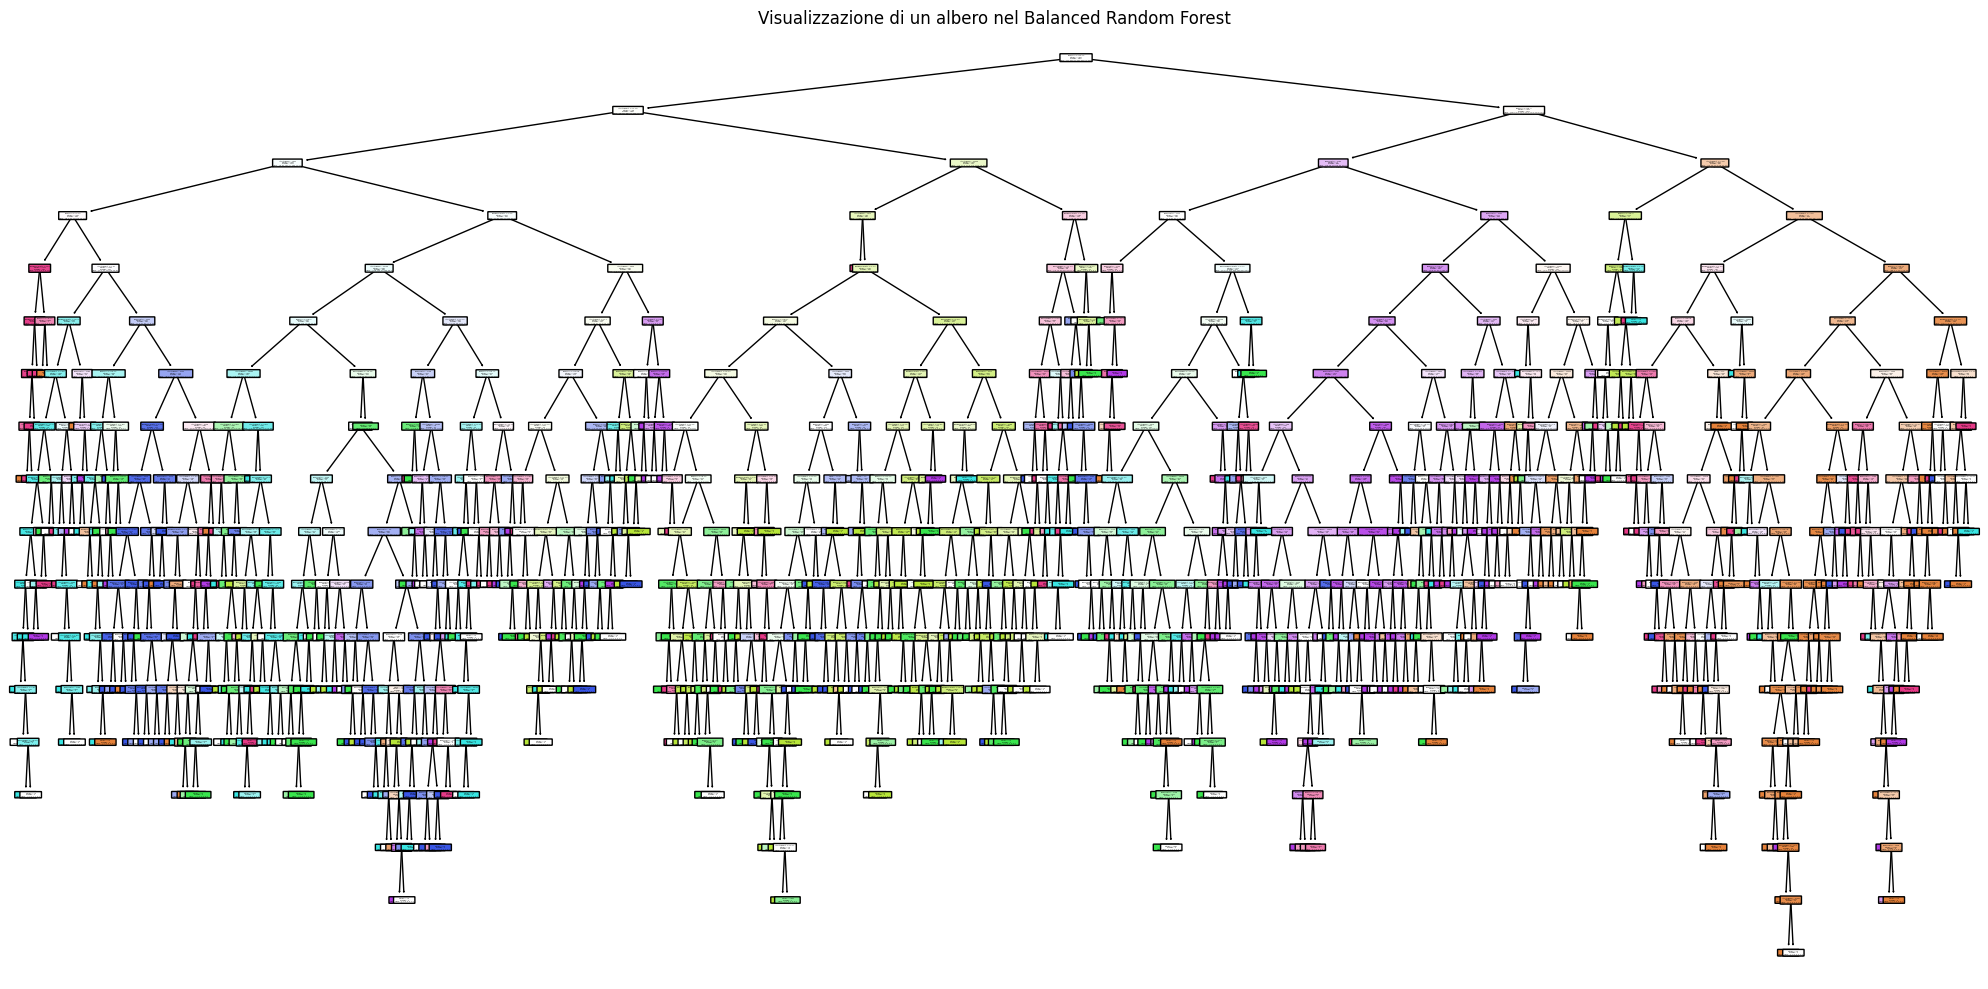


=== Metriche medie degli alberi ===
n_nodes      1212.22
max_depth      18.72
dtype: float64


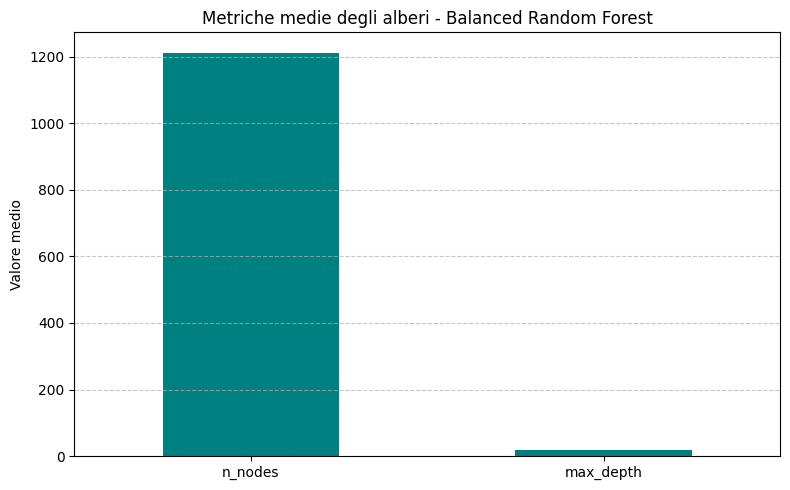

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd

print("\n=== Albero di decisione ===")

plt.figure(figsize=(20, 10))
plot_tree(
    best_clf.estimators_[0],
    feature_names=feature_columns,
    class_names=[legends[i] for i in best_clf.classes_],
    filled=True,
    rounded=True,
)
plt.title("Visualizzazione di un albero nel Balanced Random Forest")
plt.tight_layout()
plt.show()

print("\n=== Metriche medie degli alberi ===")
metrics = {
    'n_nodes': [est.tree_.node_count for est in best_clf.estimators_],
    'max_depth': [est.tree_.max_depth for est in best_clf.estimators_]
}
metrics_df = pd.DataFrame(metrics)
print(metrics_df.mean())

# === 3. Visualizzazione delle metriche medie ===
metrics_df.mean().plot(kind='bar', figsize=(8, 5), color='teal')
plt.title('Metriche medie degli alberi - Balanced Random Forest')
plt.ylabel('Valore medio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\marco\AppData\Local\Temp\ipykernel_29808\1726125804.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


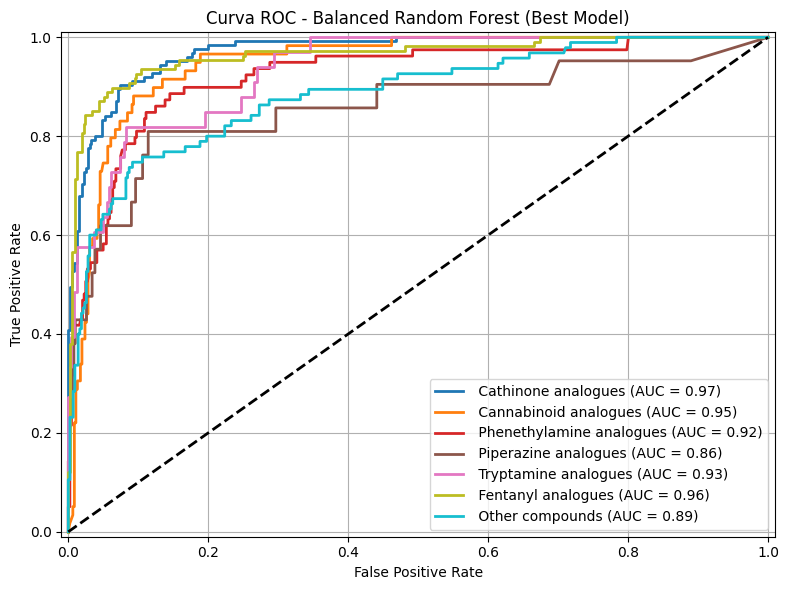

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_clf.predict_proba(x_test)

# Calcolo della curva ROC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f" {class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest (Best Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
joblib.dump(best_clf, 'model/balanced_random_forest_brf_hmp.pkl')

# Salva il test set del BRF per il confronto finale
x_test_brf = x_test.copy()


In [26]:
spectrum_dataset= nps_dataset.copy().drop(columns=['Name'])
print(f'The spectrum dataset has {spectrum_dataset.shape[0]} instances and {spectrum_dataset.shape[1]} features.')
spectrum_dataset.head()

The spectrum dataset has 2600 instances and 601 features.


,1,2,3,4,5,6,7,8,9,10,...,592,593,594,595,596,597,598,599,600,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [27]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
#import graphviz

model = keras.Sequential(name = 'dnn')
model.add(keras.Input(shape=(600,)))
model.add(layers.Dense(300, activation = 'relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(30, activation = 'relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(7, activation = 'softmax'))

from tensorflow.keras.utils import plot_model
print(model.summary())

plot_model(model, to_file="dnn_model_structure.png", show_shapes=True, show_layer_names=True, dpi=96,)

Model: "dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       180,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         9,030 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,547 (740.42 KB)

 Trainable params: 189,547 (740.42 KB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.


In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'],
)

Y = spectrum_dataset['label']
X = spectrum_dataset.drop(['label'], axis=1)

X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f'The training set has {x_train.shape[0]} instances and {x_train.shape[1]} features.')
print(f'The test set has {x_test.shape[0]} instances and {x_test.shape[1]} features.')

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print(pd.Series(y_train).value_counts())

# oversampling
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

print(pd.Series(y_train).value_counts())

early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=5,            
    restore_best_weights=True 
)

history= model.fit(
    x_train, y_train,  
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop] 
)

(2600, 600) (2600,)
The training set has 2080 instances and 600 features.
The test set has 520 instances and 600 features.
0    505
5    413
6    392
2    321
1    233
4    129
3     87
Name: count, dtype: int64
0    505
2    505
5    505
4    505
1    505
6    505
3    505
Name: count, dtype: int64
Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4590 - loss: 1.5354 - val_accuracy: 0.3692 - val_loss: 1.8607
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6584 - loss: 0.9970 - val_accuracy: 0.4173 - val_loss: 1.5701
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7288 - loss: 0.8214 - val_accuracy: 0.5290 - val_loss: 1.2634
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7652 - loss: 0.6943 - val_accuracy: 0.5912 - val_loss: 1.0858
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7974 - loss: 0.6080 - val_accuracy: 0.6648 - val_loss: 0.8445
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8218 

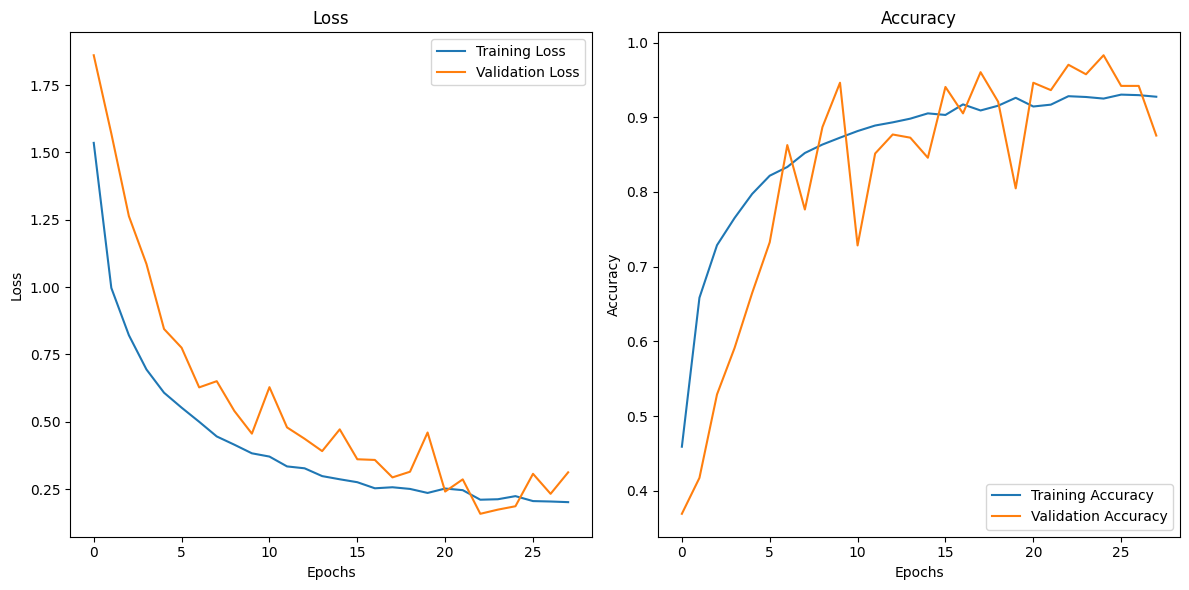

In [29]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== Classification Report ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.86      0.79      0.82       121
   Cannabinoid analogues       0.76      0.63      0.69        65
Phenethylamine analogues       0.67      0.72      0.69        75
    Piperazine analogues       0.55      0.69      0.61        16
    Tryptamine analogues       0.44      0.63      0.52        35
      Fentanyl analogues       0.85      0.88      0.87       126
         Other compounds       0.67      0.61      0.64        82

                accuracy                           0.74       520
               macro avg       0.69      0.71      0.69       520
            weighted avg       0.75      0.74      0.74       520


=== Confusion Matrix ===


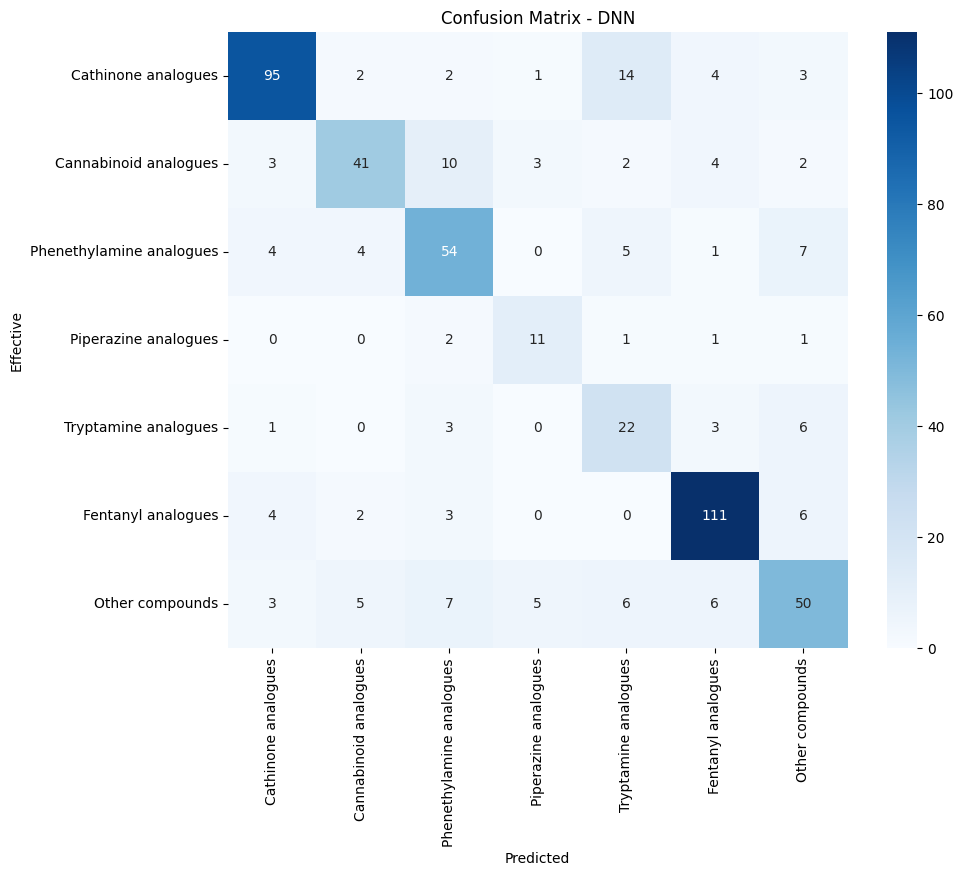

In [30]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_classes, target_names=class_labels))
print("\n=== Confusion Matrix ===")
confusion_matrix_result = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DNN')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


C:\Users\marco\AppData\Local\Temp\ipykernel_29808\1087730433.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


<Figure size 800x600 with 0 Axes>

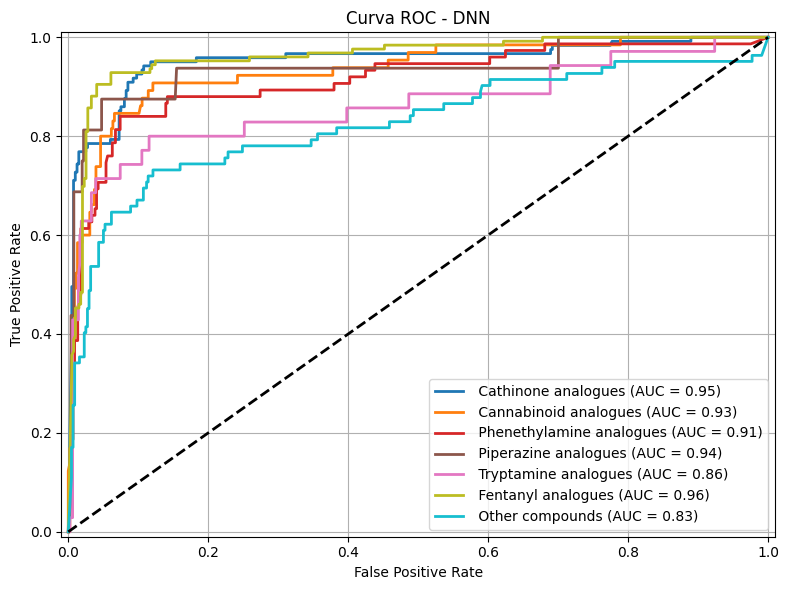

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model.predict(x_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(8, 6))
# === Plot della curva ROC ===
n_classes = len(classes)
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
                label=f" {class_labels[i]} (AUC = {roc_auc[i]:.2f})")
# Linea di riferimento
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - DNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
model.save('model/dnn_spectra_version.keras')
joblib.dump(scaler, "model/scale_dnn.pkl")

['model/scale_dnn.pkl']

# CONFRONTO CON MODELLI ORIGINALI DI CLAUDIO

In [33]:
# === Allineamento per confronto con il modello originale ===
import joblib

# Carica il modello originale per conoscere le sue feature
brf_original = joblib.load("model/Claudio/balanced_random_forest_brf.pkl")

# Se il vecchio modello ha meno feature, riduci x_test alle prime n colonne
if hasattr(brf_original, "n_features_in_"):
    n_features_old = brf_original.n_features_in_
    print(f"[INFO] Il modello originale BRF si aspetta {n_features_old} feature, ne uso le prime {n_features_old}.")
    x_test_brf_old = x_test[:, :n_features_old]
else:
    x_test_brf_old = x_test


c:\Users\marco\Desktop\Marco\Universita\Magistrale\Traineeship\Progetto\Pention-System\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[INFO] Il modello originale BRF si aspetta 9 feature, ne uso le prime 9.




🎯 Confronto BalancedRandomForest: modello nuovo vs originale (Claudio)

✅ Accuracy (Nuovo modello): 0.1712
🔁 Accuracy (Originale Claudio): 0.1442


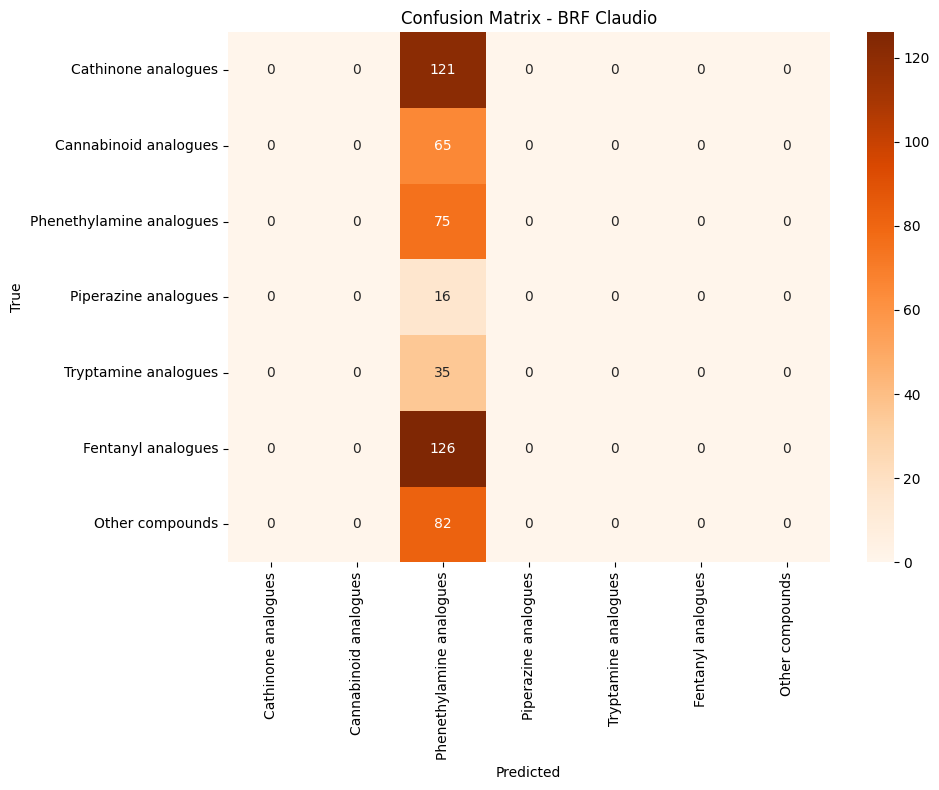



🎯 Confronto DNN: modello nuovo vs originale (Claudio)
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

✅ Accuracy (Nuovo DNN): 0.7385
🔁 Accuracy (Originale Claudio): 0.3250

=== Classification Report DNN (Originale Claudio) ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.00      0.00      0.00       121
   Cannabinoid analogues       0.05      0.06      0.05        65
Phenethylamine analogues       0.64      0.43      0.51        75
    Piperazine analogues       0.13      0.88      0.22        16
    Tryptamine analogues       0.40      0.40      0.40        35
      Fentanyl analogues       0.72      0.54      0.62       126
         Other compounds       0.40      0.45      0.42        82

                accuracy                           0.33       520
               macro avg       0.33      0.39      0.32       520
            weighted avg       0.37      0.33      0.33       520



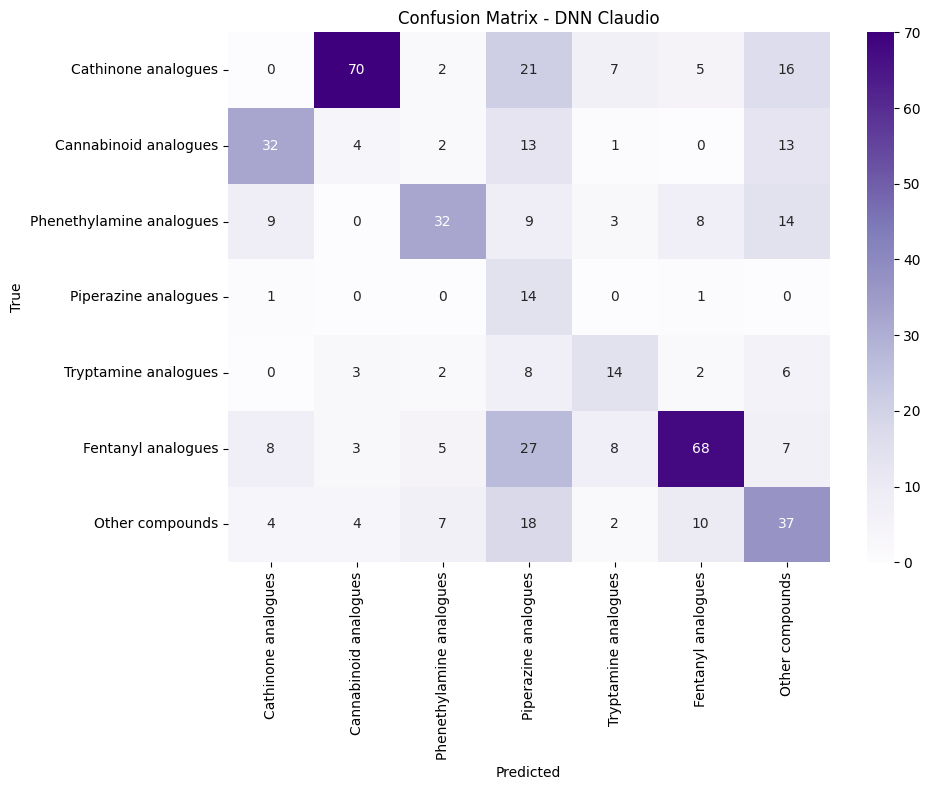

In [34]:
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import load_model

# === 1. Confronto BalancedRandomForest ===
print("\n\n🎯 Confronto BalancedRandomForest: modello nuovo vs originale (Claudio)")

# Usa le stesse feature e split già usati prima
y_pred_new = best_clf.predict(x_test_brf)
y_pred_old = brf_original.predict(x_test_brf_old)

acc_new = accuracy_score(y_test, y_pred_new)
acc_old = accuracy_score(y_test, y_pred_old)

print(f"\n✅ Accuracy (Nuovo modello): {acc_new:.4f}")
print(f"🔁 Accuracy (Originale Claudio): {acc_old:.4f}")

# Confusion matrix
confusion_matrix_result = confusion_matrix(y_test, y_pred_old)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - BRF Claudio')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
plt.tight_layout()
plt.show()

# === 2. Confronto DNN ===

print("\n\n🎯 Confronto DNN: modello nuovo vs originale (Claudio)")
dnn_original = load_model("model/Claudio/dnn_spectra_version.keras")

# Predizioni
y_pred_dnn_new = model.predict(x_test)
y_pred_dnn_old = dnn_original.predict(x_test)

y_classes_new = np.argmax(y_pred_dnn_new, axis=1)
y_classes_old = np.argmax(y_pred_dnn_old, axis=1)

acc_new_dnn = accuracy_score(y_test, y_classes_new)
acc_old_dnn = accuracy_score(y_test, y_classes_old)

print(f"\n✅ Accuracy (Nuovo DNN): {acc_new_dnn:.4f}")
print(f"🔁 Accuracy (Originale Claudio): {acc_old_dnn:.4f}")

print("\n=== Classification Report DNN (Originale Claudio) ===")
print(classification_report(y_test, y_classes_old, target_names=class_labels))

# Confusion Matrix
confusion_matrix_result = confusion_matrix(y_test, y_classes_old)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DNN Claudio')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
plt.tight_layout()
plt.show()
